In [1]:
from test_nuradio_single import NuRadioRecoReader
from NuRadioReco.detector import detector
from NuRadioReco.detector.SKA.detector import Detector as SKADetector
from NuRadioReco.utilities import units
from NuRadioReco.detector.antennapattern import preprocess_LOFAR_txt
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors

ERROR - 2026-08-07 17:04:22,524 - NuRadioReco.channelGalacticNoiseAdder - pylfmap import failed. This might be because you do not have a working installation of cfitsio. See https://github.com/F-Tomas/pylfmap/issues/2 for potential tips


In [15]:
# path_to_response = "/home/rkitahara/Research/Cov/test_simulation/antenna_response_lofar"
path_to_response = "/home/rkitahara/Research/Cov/SKA_Cov/antenna_response_ska/Vogel/telescope.tm"

path_to_coreas_sim_file = "/home/rkitahara/Research/Cov/test_simulation/93970574/0/proton/SIM000018.hdf5"

# det = detector.Detector(
#     "LOFAR/LOFAR.json", source="json", antenna_by_depth=False
# )
det = SKADetector(position_path=path_to_response, maximum_radius=30 * units.m)
# det.update(datetime.datetime(2013, 1, 1, 0, 0, 0))

selected_station_channel_ids = {}
# for staid in [1, 2, 3, 4, 5, 6, 7]:
#     selected_station_channel_ids[staid] = det.get_channel_ids(staid)
decimation = 200
for staid in det.get_station_ids():
    selected_station_channel_ids[staid] = np.sort(np.concatenate([det.get_channel_ids(staid)[0::2][::decimation],
                                                                    det.get_channel_ids(staid)[1::2][::decimation]]))

core_xy = np.array([0, 0]) * units.m

# preprocess_LOFAR_txt(path_to_response, orientation="Y")
# preprocess_LOFAR_txt(path_to_response, orientation="X")

In [16]:
selected_station_channel_ids

{np.int64(4): array([   0,    1, 2000, 2001])}

In [17]:
reader = NuRadioRecoReader(det,filt_settings={"passband": [50 * units.MHz, 350 * units.MHz], "filter_type": "butter", "order": 10})

evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=60 * units.K)

STATUS - 2026-08-07 17:18:23,411 - NuRadioReco.antennapattern - Loading antenna file SKALA_v4_Xpol took 0.2 seconds


STATUS - 2026-08-07 17:18:23,612 - NuRadioReco.antennapattern - Loading antenna file SKALA_v4_Ypol took 0.2 seconds


Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
[np.int64(10), np.int64(11), np.int64(20), np.int64(21), np.int64(30), np.int64(31), np.int64(40), np.int64(41), np.int64(50), np.int64(51), np.int64(60), np.int64(61), np.int64(70), np.int64(71), np.int64(80), np.int64(81), np.int64(90), np.int64(91), np.int64(100), np.int64(101), np.int64(110), np.int64(111), np.int64(120), np.int64(121), np.int64(130), np.int64(131), np.int64(140), np.int64(141), np.int64(150), np.int64(151), np.int64(160), np.int64(161), np.int64(170), np.int64(171), np.int64(180), np.int64(181), np.int64(190), np.int64(191), np.int64(200), np.int64(201), np.int64(210), np.int64(211), np.int64(220), np.int64(221), np.int64(230), np.int64(231), np.int64(240), np.int64(241), np.int64(250), np.int64(251), np.int64(260), np.int64(261), np.int64(270), np.int64(271), np.int64(280), np.int64(281), np.int64(290), np.int64(291), np.int64(300), np.int64(301), np.int64(310), np.int64(311), np.int64(320), np

In [5]:
len(evt.get_station_ids())

1

In [6]:
len(evt.get_station(4).get_channel_ids())

512

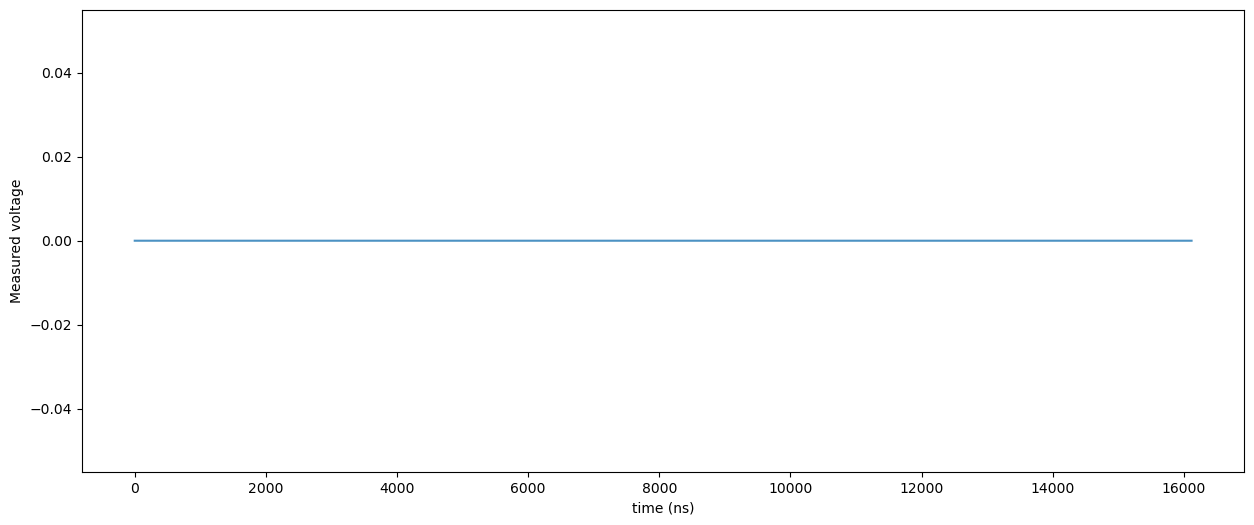

In [19]:
stn = 4
chn = 2
plt.figure(figsize=(15, 6))
# plt.plot(channel.get_trace(), label="300K")
plt.plot(evt.get_station(stn).get_channel(evt.get_station(stn).get_channel_ids()[chn]).get_trace(), label="0K", alpha=0.8)
# plt.legend()
plt.xlabel("time (ns)")
plt.ylabel("Measured voltage")
plt.savefig("pure_signal.png", dpi=300, bbox_inches="tight")
plt.show()

## Let's iterate!
### Try a few first

In [ ]:
def calc_rms(trace, length):
    return np.sqrt(np.mean(np.square(trace[:-length])))

def remove_signal(trace, sig_window, rms, threshold):
    if np.max(trace)/rms > threshold:
        sig = np.argmax(trace)
        return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1)), True
    return trace, False

def get_reals(traces, dur, sig_window, rms, threshold, fn_time):
    reals = []
    n_removed = 0
    for trace in traces:
        new, rem = remove_signal(trace, sig_window, rms, threshold)
        to_consider = new[:-(len(new)%dur)]
        reals.append(np.split(to_consider, len(to_consider)/dur))
        if rem:
            n_removed += 1
        
    print(f"{n_removed}/{len(traces)} had above SNR {threshold} signal", flush=True)
    # with open(fn_time, 'a') as f:
    #     f.write(f"{n_removed}/{len(traces)} had above SNR {threshold} signal \n")

    return np.vstack(reals)

def make_cov(traces, duration, sig_window, rms_window, threshold, fn_time):
    rms = calc_rms(traces[0], rms_window)
    reals = np.array(get_reals(traces, duration, sig_window, rms, threshold, fn_time))
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

In [13]:
traces = []
for i in range(10):
    evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=60 * units.K)
    traces.append(evt.get_station(4).get_channel(evt.get_station(4).get_channel_ids()[0]).get_trace()[::12])
    traces.append(evt.get_station(4).get_channel(evt.get_station(4).get_channel_ids()[1]).get_trace()[::12])
traces = np.array(traces)

Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V


In [34]:
cov, N = make_cov(traces, 800, 200, 50, 5., "yeah")

12/20 had above SNR 5.0 signal


In [28]:
def draw_cov(cov, N, dur, dirname, evt_name):
    # Make plots
    plt.figure()
    sns.heatmap(cov, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
    plt.suptitle(evt_name)
    plt.title(f"Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    # fn = os.path.join(dirname, "cov.png")
    # plt.savefig(fn, dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    

def draw_1D(cov, x_time, dur, dirname, evt_name):
    # Plot!
    plt.figure(figsize=(12,6))
    plt.axhline(y=0, c="gray", linestyle="--")
    plt.plot(x_time[:100], cov[0, :100])
    plt.scatter(x_time[:100], cov[0, :100], marker=".")

    plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
    plt.ylabel(r"Cov($\Delta t_{i,j}$)")
    
    plt.suptitle(evt_name)
    plt.title(f"1D function of the first row for first 100 bins. Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    # fn = os.path.join(dirname, "1d.pdf")
    # plt.savefig(fn, format="pdf")
    # plt.close()
    plt.show()

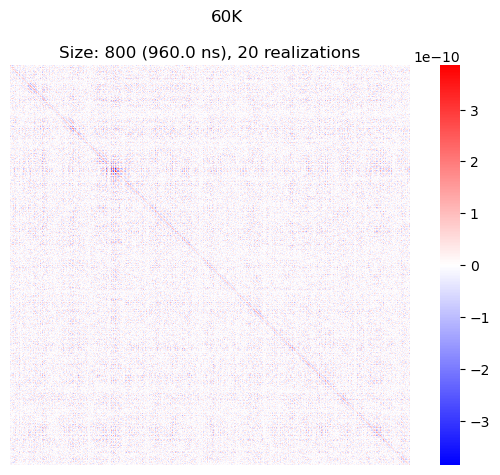

In [38]:
draw_cov(cov,N, 800, "year", "60K")

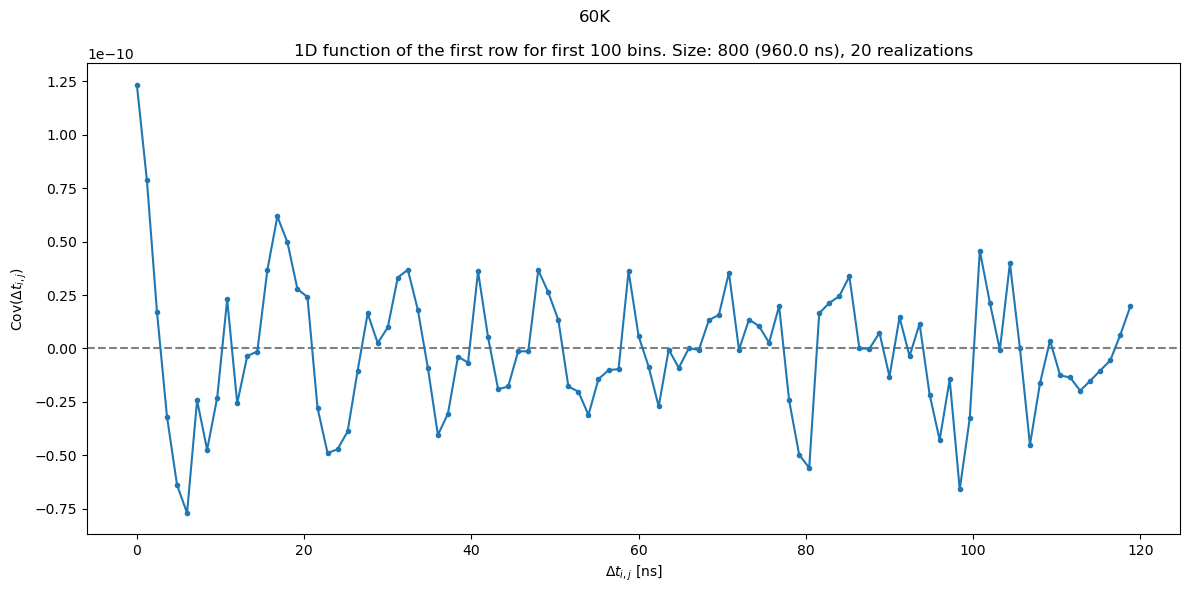

In [37]:
draw_1D(cov, np.arange(200)*1.2, 800, "yea", "60K")

## 200K
### 500 times!

In [1]:
from test_nuradio_single import NuRadioRecoReader
from NuRadioReco.detector import detector
from NuRadioReco.detector.SKA.detector import Detector as SKADetector
from NuRadioReco.utilities import units
from NuRadioReco.detector.antennapattern import preprocess_LOFAR_txt
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import os

ERROR - 2026-08-08 14:45:29,786 - NuRadioReco.channelGalacticNoiseAdder - pylfmap import failed. This might be because you do not have a working installation of cfitsio. See https://github.com/F-Tomas/pylfmap/issues/2 for potential tips


In [12]:
def calc_rms(trace, length):
    return np.sqrt(np.mean(np.square(trace[:-length])))

def remove_signal(trace, sig_window, rms, threshold):
    if np.max(trace)/rms > threshold:
        sig = np.argmax(trace)
        return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1)), True
    return trace, False

def get_reals(traces, dur, sig_window, rms, threshold):
    reals = []
    n_removed = 0
    for trace in traces:
        new, rem = remove_signal(trace, sig_window, rms, threshold)
        to_consider = new[:-(len(new)%dur)]
        reals.append(np.split(to_consider, len(to_consider)/dur))
        if rem:
            n_removed += 1
        
    print(f"{n_removed}/{len(traces)} had above SNR {threshold} signal", flush=True)
    # with open(fn_time, 'a') as f:
    #     f.write(f"{n_removed}/{len(traces)} had above SNR {threshold} signal \n")

    return np.vstack(reals)

def make_cov(traces, duration, sig_window, rms_window, threshold):
    rms = calc_rms(traces[0], rms_window)
    reals = np.array(get_reals(traces, duration, sig_window, rms, threshold))
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

def draw_cov(cov, N, dur, display_bin, evt_name, dirname):
    # Make plots
    plt.figure()
    sns.heatmap(cov, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
    plt.suptitle(evt_name)
    plt.title(f"Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, "cov.png")
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    plt.figure()
    sns.heatmap(cov[:display_bin, :display_bin], xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
    plt.suptitle(f"{evt_name}; First {display_bin} bins")
    plt.title(f"Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, f"cov_{display_bin}.png")
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    

def draw_1D(cov, x_time, dur, display_bin, evt_name, dirname):
    # Plot!
    plt.figure(figsize=(12,6))
    plt.axhline(y=0, c="gray", linestyle="--")
    plt.plot(x_time[:display_bin], cov[0, :display_bin])
    plt.scatter(x_time[:display_bin], cov[0, :display_bin], marker=".")

    plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
    plt.ylabel(r"Cov($\Delta t_{i,j}$)")
    
    plt.suptitle(evt_name)
    plt.title(f"1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, "1d.pdf")
    plt.savefig(fn, format="pdf")
    # plt.close()
    plt.show()

In [3]:
# path_to_response = "/home/rkitahara/Research/Cov/test_simulation/antenna_response_lofar"
path_to_response = "/home/rkitahara/Research/Cov/SKA_Cov/antenna_response_ska/Vogel/telescope.tm"

path_to_coreas_sim_file = "/home/rkitahara/Research/Cov/test_simulation/93970574/0/proton/SIM000018.hdf5"

# det = detector.Detector(
#     "LOFAR/LOFAR.json", source="json", antenna_by_depth=False
# )
det = SKADetector(position_path=path_to_response, maximum_radius=30 * units.m)
# det.update(datetime.datetime(2013, 1, 1, 0, 0, 0))

selected_station_channel_ids = {}
# for staid in [1, 2, 3, 4, 5, 6, 7]:
#     selected_station_channel_ids[staid] = det.get_channel_ids(staid)
decimation = 200
for staid in det.get_station_ids():
    selected_station_channel_ids[staid] = np.sort(np.concatenate([det.get_channel_ids(staid)[0::2][::decimation],
                                                                    det.get_channel_ids(staid)[1::2][::decimation]]))

core_xy = np.array([0, 0]) * units.m

# preprocess_LOFAR_txt(path_to_response, orientation="Y")
# preprocess_LOFAR_txt(path_to_response, orientation="X")

In [4]:
reader = NuRadioRecoReader(det,filt_settings={"passband": [50 * units.MHz, 350 * units.MHz], "filter_type": "butter", "order": 10})
traces = []
for i in range(500):
    evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=60 * units.K)
    traces.append(evt.get_station(4).get_channel(evt.get_station(4).get_channel_ids()[0]).get_trace()[::12])
    traces.append(evt.get_station(4).get_channel(evt.get_station(4).get_channel_ids()[1]).get_trace()[::12])
traces = np.array(traces)

STATUS - 2026-08-08 14:45:44,206 - NuRadioReco.antennapattern - Loading antenna file SKALA_v4_Xpol took 0.2 seconds


STATUS - 2026-08-08 14:45:44,433 - NuRadioReco.antennapattern - Loading antenna file SKALA_v4_Ypol took 0.2 seconds


Calculated Vrms: 3.53e-06 V, applying noise with amplitude 4.07e-06 V
[np.int64(10), np.int64(11), np.int64(20), np.int64(21), np.int64(30), np.int64(31), np.int64(40), np.int64(41), np.int64(50), np.int64(51), np.int64(60), np.int64(61), np.int64(70), np.int64(71), np.int64(80), np.int64(81), np.int64(90), np.int64(91), np.int64(100), np.int64(101), np.int64(110), np.int64(111), np.int64(120), np.int64(121), np.int64(130), np.int64(131), np.int64(140), np.int64(141), np.int64(150), np.int64(151), np.int64(160), np.int64(161), np.int64(170), np.int64(171), np.int64(180), np.int64(181), np.int64(190), np.int64(191), np.int64(200), np.int64(201), np.int64(210), np.int64(211), np.int64(220), np.int64(221), np.int64(230), np.int64(231), np.int64(240), np.int64(241), np.int64(250), np.int64(251), np.int64(260), np.int64(261), np.int64(270), np.int64(271), np.int64(280), np.int64(281), np.int64(290), np.int64(291), np.int64(300), np.int64(301), np.int64(310), np.int64(311), np.int64(320), np

In [7]:
dur = 800
sig_window = 200
noise_window = 50
threshold = 5.
dirname = f"results/200K_1000samples_size{dur}"
cov, N = make_cov(traces, dur, sig_window, noise_window, threshold)

503/1000 had above SNR 5.0 signal


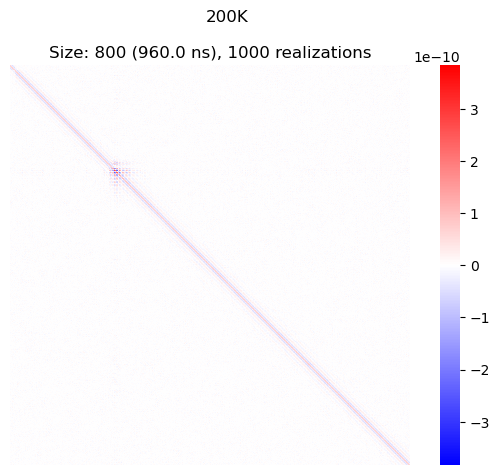

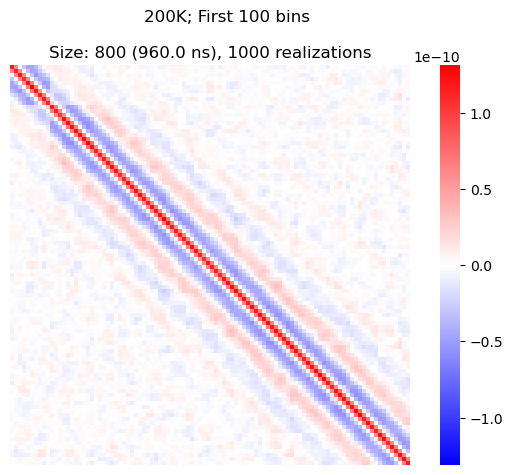

In [13]:
display_bin = 100
draw_cov(cov, N, dur, display_bin, "200K", dirname)

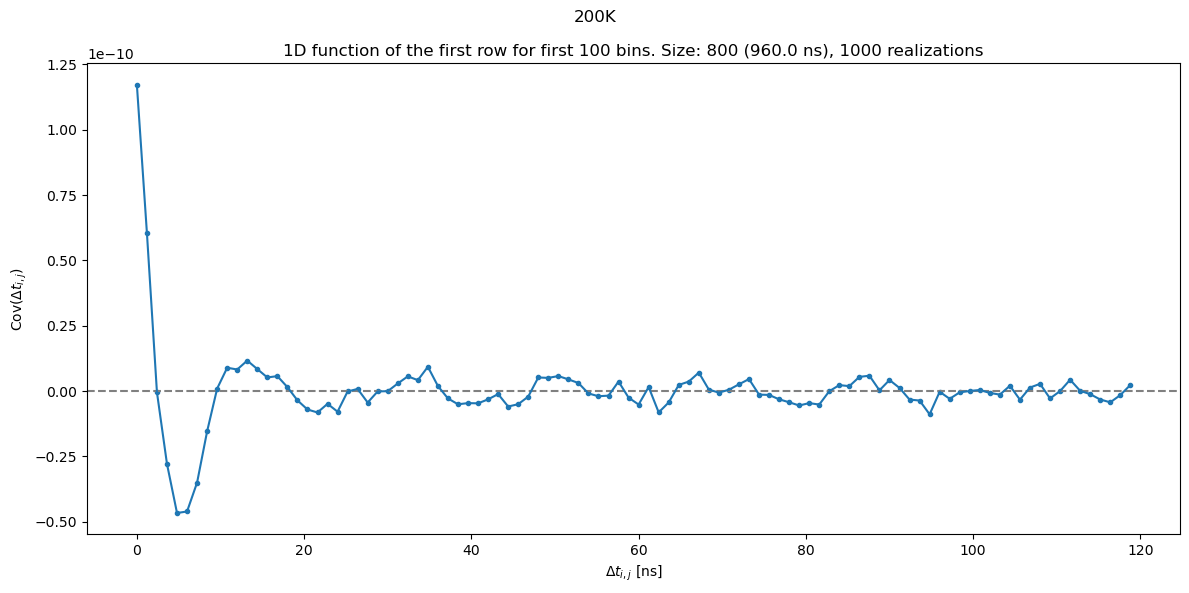

In [14]:
draw_1D(cov, np.arange(dur)*1.2, dur, display_bin, "200K", dirname)

In [11]:
np.save(f"{dirname}/traces.npy", traces)
np.save(f"{dirname}/Cov.npy", cov)

# 60K

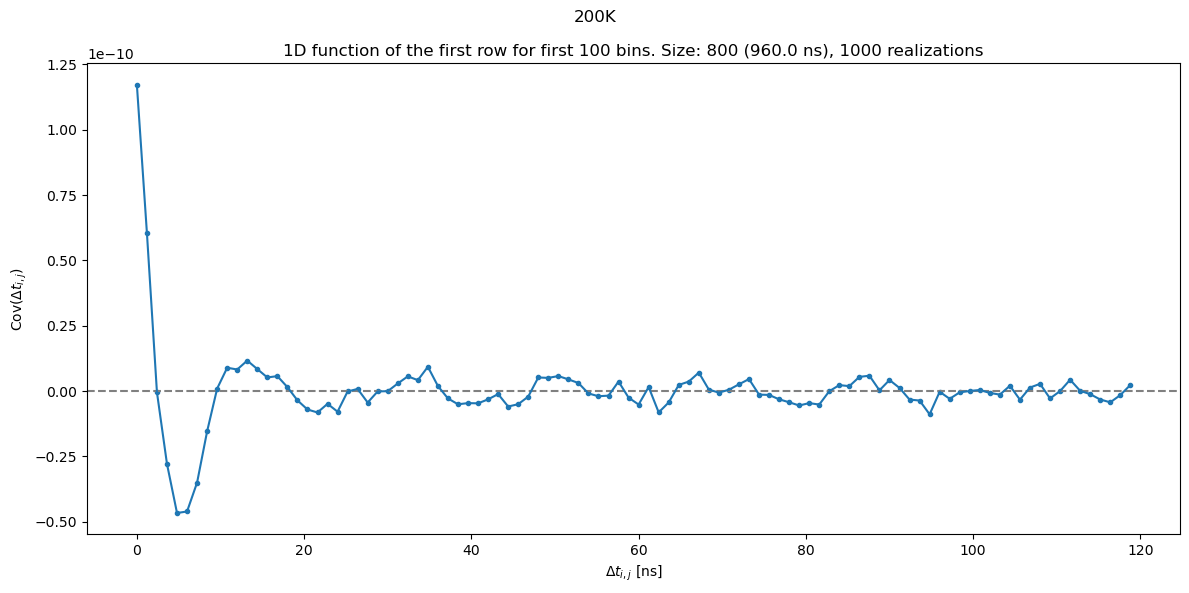

In [ ]:
draw_1D(cov, np.arange(dur)*1.2, dur, 100, "200K", dirname)